# ML - Aprendizaje No Supervisado: Cáncer de Boca con K-Means

Si bien la mayoría de los ejemplos de *Machine Learning* que se presentan de forma introductoria suelen basarse en aprendizaje supervisado, en muchos casos reales los datos no están etiquetados. En esta práctica vamos a usar técnicas de aprendizaje no supervisado para agrupar imágenes de cáncer de boca por similitud visual. Para facilitar la interpretación, primero convertimos las imágenes a escala de grises, las redimensionamos y luego aplicamos PCA y K-Means. El valor de k no depende del número de muestras, sino de cuántos grupos queremos y qué tan bien se separan visualmente; por eso aquí se justifica con la estructura de las imágenes y no con el tamaño del dataset.


## 1. Carga del dataset local

Buscamos imágenes dentro de `C:\Users\elmer\Documents\SIS420\archive`. Para simplificar el análisis, las imágenes se convierten a escala de grises y se redimensionan antes de agruparlas. Si más adelante agregas carpetas con etiquetas, el notebook también puede detectarlas.


In [1]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, MiniBatchKMeans


plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['axes.titlesize'] = 12
plt.rcParams['axes.labelsize'] = 11

In [2]:
data_root = Path(r'C:\Users\elmer\Documents\archive\all unlabeled')
image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
image_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in image_extensions])

if not image_paths:
    raise FileNotFoundError(f'No se encontraron imágenes en {data_root}')

print(f'Imágenes encontradas: {len(image_paths)}')
print('Primeras rutas:')
for path in image_paths[:5]:
    print(' -', path)

Imágenes encontradas: 10002
Primeras rutas:
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0001.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0002.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0003.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0004.jpg
 - C:\Users\elmer\Documents\archive\all unlabeled\oral_normal_0005.jpg


In [22]:
def load_images(paths, image_size=(64, 64), max_images=None):
    selected_paths = paths if max_images is None else paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert('L').resize(image_size)
            image_arrays.append(np.asarray(img, dtype=np.float32) / 255.0)
    images = np.stack(image_arrays)
    flat = images.reshape(len(images), -1)
    return images, flat, selected_paths

max_images = None
images, X, used_paths = load_images(image_paths, image_size=(64, 64), max_images=max_images)
print('Shape de imágenes:', images.shape)
print('Shape de X:', X.shape)

Shape de imágenes: (10002, 64, 64)
Shape de X: (10002, 4096)


In [4]:
folder_labels = [p.parent.name for p in used_paths]
unique_folders = sorted(set(folder_labels))

if len(unique_folders) > 1:
    from sklearn.preprocessing import LabelEncoder
    encoder = LabelEncoder()
    y = encoder.fit_transform(folder_labels)
    target_names = encoder.classes_
    print('Etiquetas detectadas desde carpetas:', list(target_names))
else:
    y = None
    target_names = None
    print('No se detectaron etiquetas útiles. El notebook continuará como clustering + pseudoetiquetado manual.')

No se detectaron etiquetas útiles. El notebook continuará como clustering + pseudoetiquetado manual.


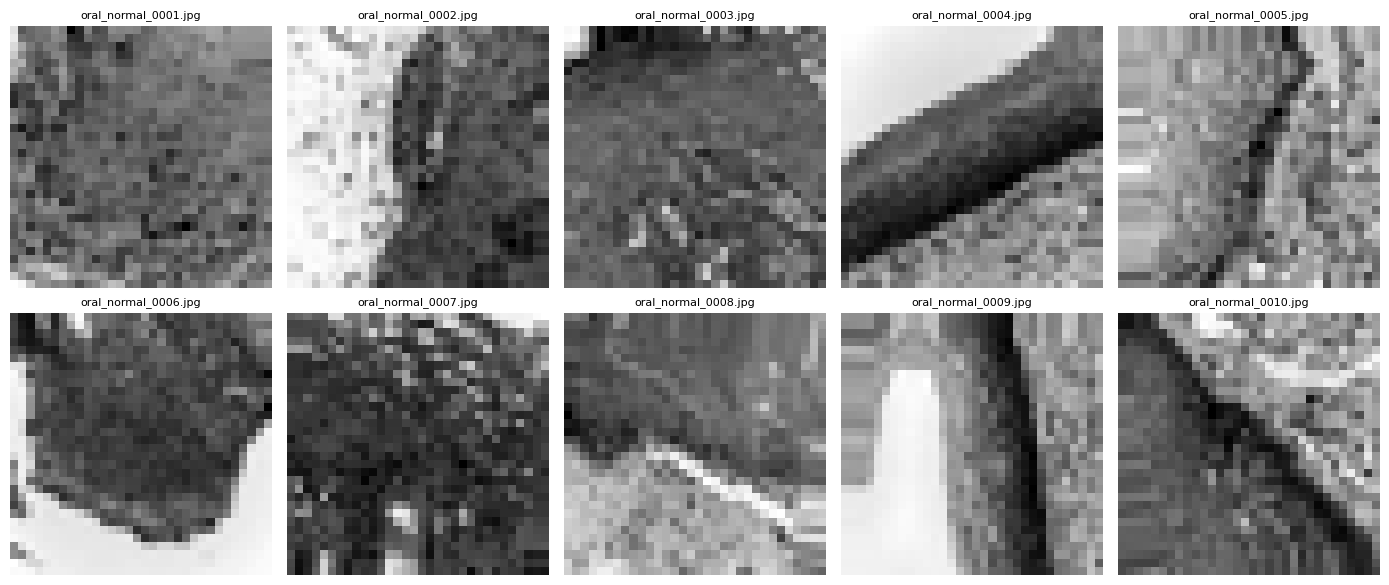

In [5]:
n_show = min(10, len(images))
cols = 5
rows = math.ceil(n_show / cols)
fig, axes = plt.subplots(rows, cols, figsize=(14, 3 * rows))
axes = np.array(axes).reshape(-1)

for idx in range(len(axes)):
    axes[idx].axis('off')

for idx in range(n_show):
    axes[idx].imshow(images[idx], cmap='gray')
    title = used_paths[idx].name
    axes[idx].set_title(title[:22], fontsize=8)

plt.tight_layout()
plt.show()

Silhouette score del clustering real (muestra de 2000 imágenes): 0.1443


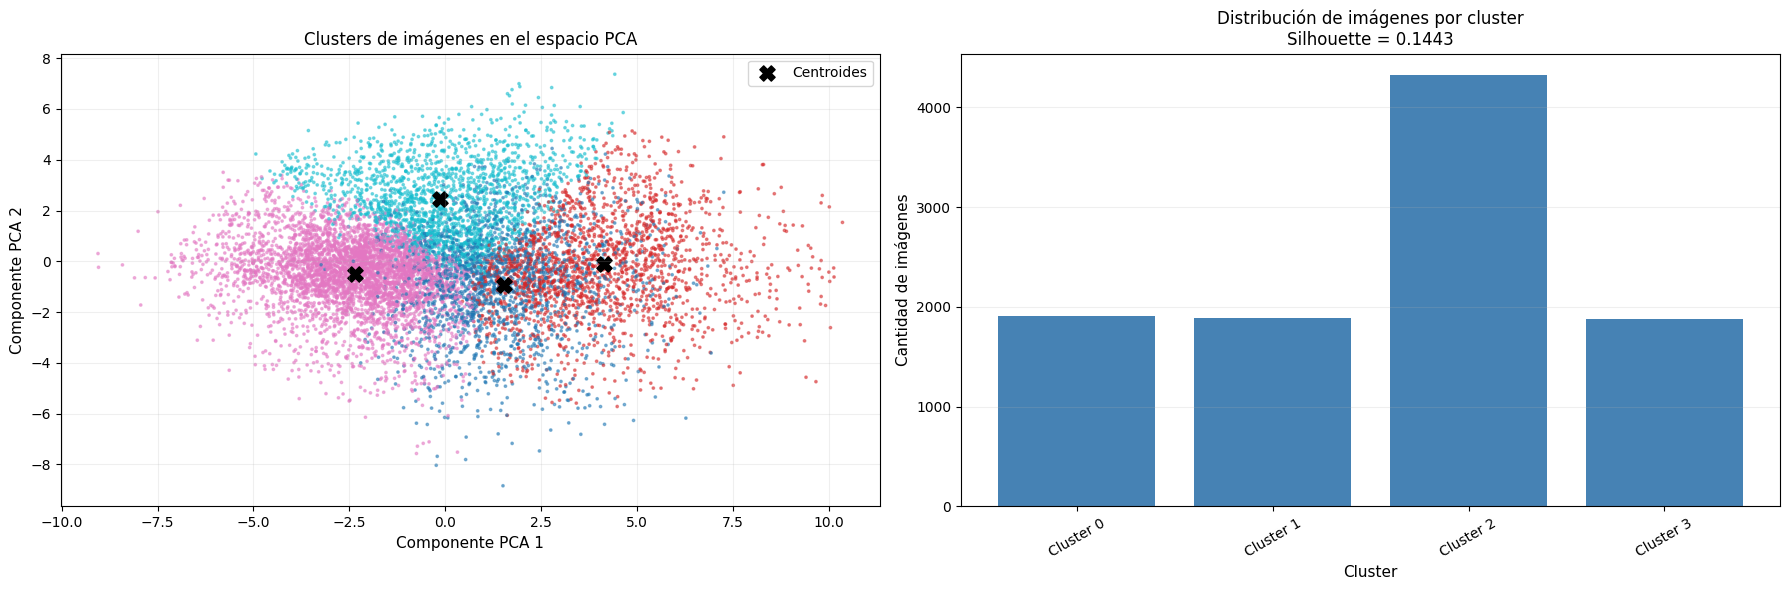

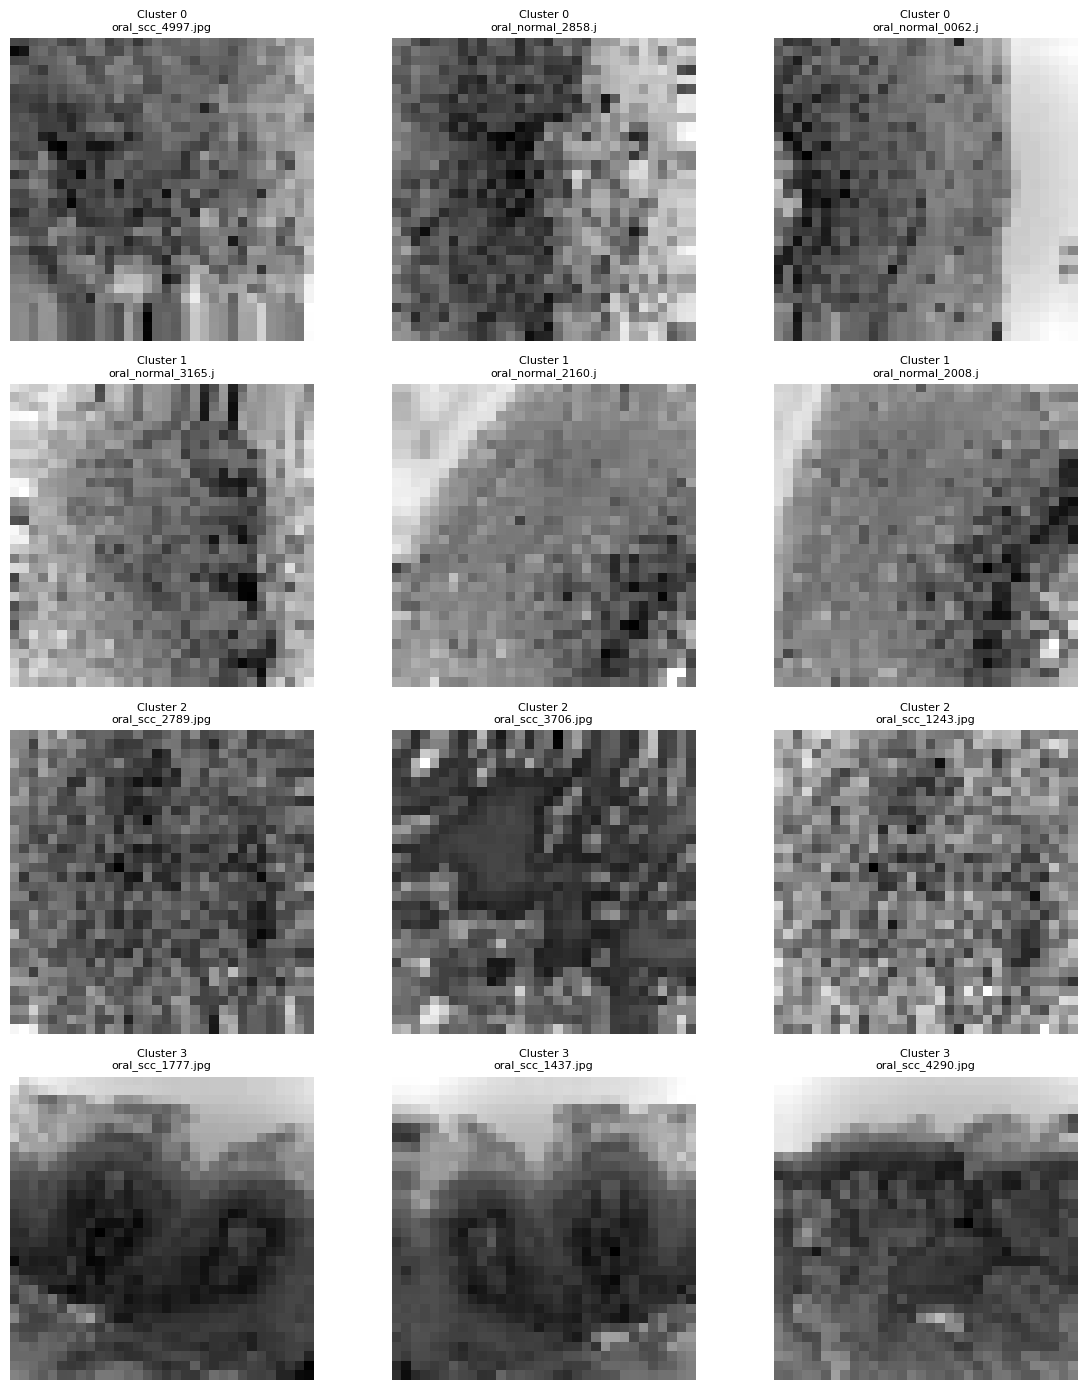

In [8]:
from sklearn.metrics import silhouette_score

if 'X_reduced' not in globals():
    pca_components = min(50, X.shape[1], X.shape[0] - 1)
    pca = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
    X_reduced = pca.fit_transform(X)

if 'kmeans' not in globals() or 'cluster_ids' not in globals():
    kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=256, n_init=10)
    cluster_ids = kmeans.fit_predict(X_reduced)

sample_size = min(2000, len(X_reduced))
rng = np.random.RandomState(42)
sample_indices = rng.choice(len(X_reduced), size=sample_size, replace=False)
X_sample = X_reduced[sample_indices]
cluster_sample = cluster_ids[sample_indices]

sil_score_real = silhouette_score(X_sample, cluster_sample)
print(f'Silhouette score del clustering real (muestra de {sample_size} imágenes): {sil_score_real:.4f}')

cluster_unique, cluster_counts = np.unique(cluster_ids, return_counts=True)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

axes[0].scatter(X_reduced[:, 0], X_reduced[:, 1], c=cluster_ids, cmap='tab10', s=3, alpha=0.5)
axes[0].scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1], c='black', s=120, marker='X', label='Centroides')
axes[0].set_title('Clusters de imágenes en el espacio PCA')
axes[0].set_xlabel('Componente PCA 1')
axes[0].set_ylabel('Componente PCA 2')
axes[0].legend(loc='best')
axes[0].grid(alpha=0.2)

axes[1].bar([f'Cluster {cluster_id}' for cluster_id in cluster_unique], cluster_counts, color='steelblue')
axes[1].set_title(f'Distribución de imágenes por cluster\nSilhouette = {sil_score_real:.4f}')
axes[1].set_xlabel('Cluster')
axes[1].set_ylabel('Cantidad de imágenes')
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.2)

plt.tight_layout()
plt.show()

montage_images = []
montage_titles = []
for cluster_id in cluster_unique:
    cluster_positions = np.where(cluster_ids == cluster_id)[0]
    if len(cluster_positions) == 0:
        continue
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(X_reduced[cluster_positions] - center, axis=1)
    ordered_positions = cluster_positions[np.argsort(distances)]
    for image_index in ordered_positions[:3]:
        montage_images.append(images[image_index])
        montage_titles.append(f'Cluster {cluster_id}\n{used_paths[image_index].name[:18]}')

montage_cols = 3
montage_rows = math.ceil(len(montage_images) / montage_cols)
fig, axes = plt.subplots(montage_rows, montage_cols, figsize=(4 * montage_cols, 3.5 * montage_rows))
axes = np.array(axes).reshape(-1)

for axis in axes:
    axis.axis('off')

for axis, img, title in zip(axes, montage_images, montage_titles):
    axis.imshow(img, cmap='gray')
    axis.set_title(title, fontsize=8)

plt.tight_layout()
plt.show()

### K-Means

El algoritmo de *K-Means* es uno de los métodos más conocidos para hacer *Clustering*, ya que es rápido y sencillo de interpretar. En esta práctica lo usaremos con imágenes locales que primero se reducen a escala de grises y luego se redimensionan a 32x32 antes de aplicar PCA y K-Means. Eso simplifica el análisis y ayuda a entender mejor los grupos visuales.


In [23]:
pca_components = min(50, X.shape[1], X.shape[0] - 1)
pca = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
X_reduced = pca.fit_transform(X)

print('Shape de X reducido:', X_reduced.shape)
print('Varianza explicada acumulada:', round(pca.explained_variance_ratio_.sum(), 4))

Shape de X reducido: (10002, 50)
Varianza explicada acumulada: 0.7679


## 3. Elegir el número de clusters

Como el objetivo aquí es una presentación simple y fácil de interpretar, vamos a fijar `k = 4` para separar las imágenes en cuatro grupos visuales. Esto no significa que el dataset tenga etiquetas reales; los nombres como `normal` o `cancer` solo se usan después de revisar manualmente los clusters representativos.


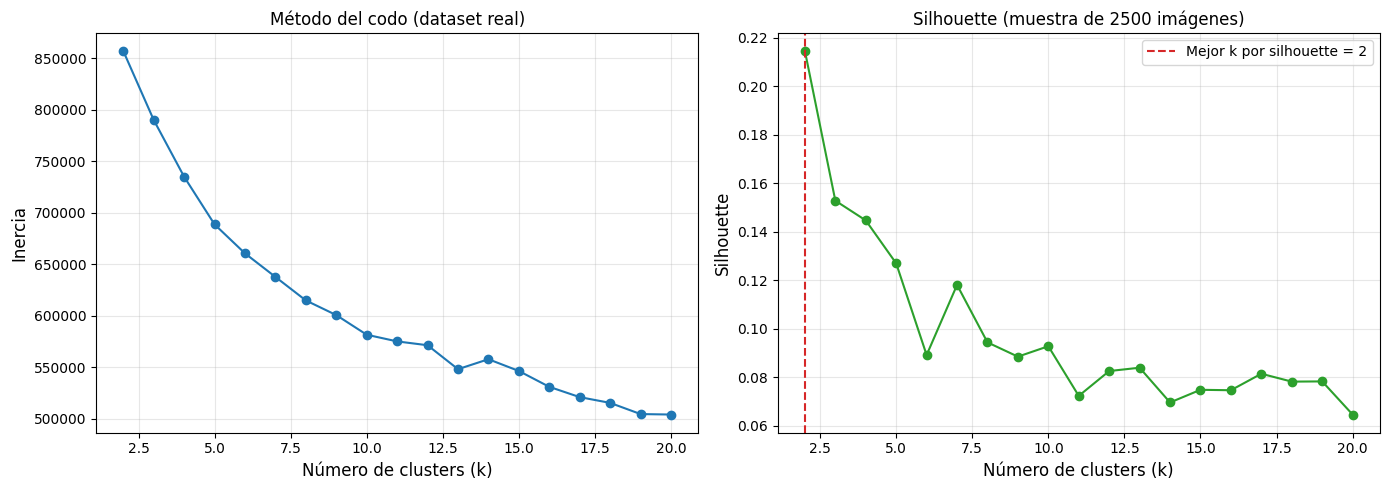

k sugerido por silhouette en dataset real: 2


In [27]:
from sklearn.metrics import silhouette_score

max_k = 20
k_values = list(range(2, max_k + 1))
inertias = []
silhouette_scores_real = []

sil_sample_size = min(2500, len(X_reduced))
rng_sil = np.random.RandomState(42)
sil_sample_idx = rng_sil.choice(len(X_reduced), size=sil_sample_size, replace=False)
X_sil = X_reduced[sil_sample_idx]

for k in k_values:
    model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10)
    labels_full = model.fit_predict(X_reduced)
    inertias.append(model.inertia_)

    labels_sil = labels_full[sil_sample_idx]
    if len(np.unique(labels_sil)) < 2:
        silhouette_scores_real.append(np.nan)
    else:
        silhouette_scores_real.append(silhouette_score(X_sil, labels_sil))

sil_array = np.array(silhouette_scores_real, dtype=float)
best_k_silhouette = k_values[int(np.nanargmax(sil_array))]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(k_values, inertias, 'o-', color='tab:blue')
axes[0].set_xlabel('Número de clusters (k)', fontsize=12)
axes[0].set_ylabel('Inercia', fontsize=12)
axes[0].set_title('Método del codo (dataset real)', fontsize=12)
axes[0].grid(True, alpha=0.3)

axes[1].plot(k_values, silhouette_scores_real, 'o-', color='tab:green')
axes[1].axvline(best_k_silhouette, color='tab:red', linestyle='--', label=f'Mejor k por silhouette = {best_k_silhouette}')
axes[1].set_xlabel('Número de clusters (k)', fontsize=12)
axes[1].set_ylabel('Silhouette', fontsize=12)
axes[1].set_title(f'Silhouette (muestra de {sil_sample_size} imágenes)', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

best_k = int(best_k_silhouette)
print(f'k sugerido por silhouette en dataset real: {best_k}')

### Método del codo

Probamos distintos valores de $k$ y usamos la inercia (*inertia*) para identificar un punto razonable de agrupamiento. El gráfico nos ayuda a ver dónde empieza a disminuir la mejora al aumentar $k$.


In [24]:
kmeans = MiniBatchKMeans(n_clusters=4, random_state=42, batch_size=256, n_init=10)
cluster_ids = kmeans.fit_predict(X_reduced)

unique_clusters, cluster_counts = np.unique(cluster_ids, return_counts=True)
print('Distribución de clusters:')
for cluster_id, count in zip(unique_clusters, cluster_counts):
    print(f' - Cluster {cluster_id}: {count} imágenes')


Distribución de clusters:
 - Cluster 0: 1917 imágenes
 - Cluster 1: 1886 imágenes
 - Cluster 2: 4316 imágenes
 - Cluster 3: 1883 imágenes


### Lectura final con k=4

Después de revisar el método del codo, se fija $k=4$ para mostrar la agrupación final y comparar la distribución de las imágenes.


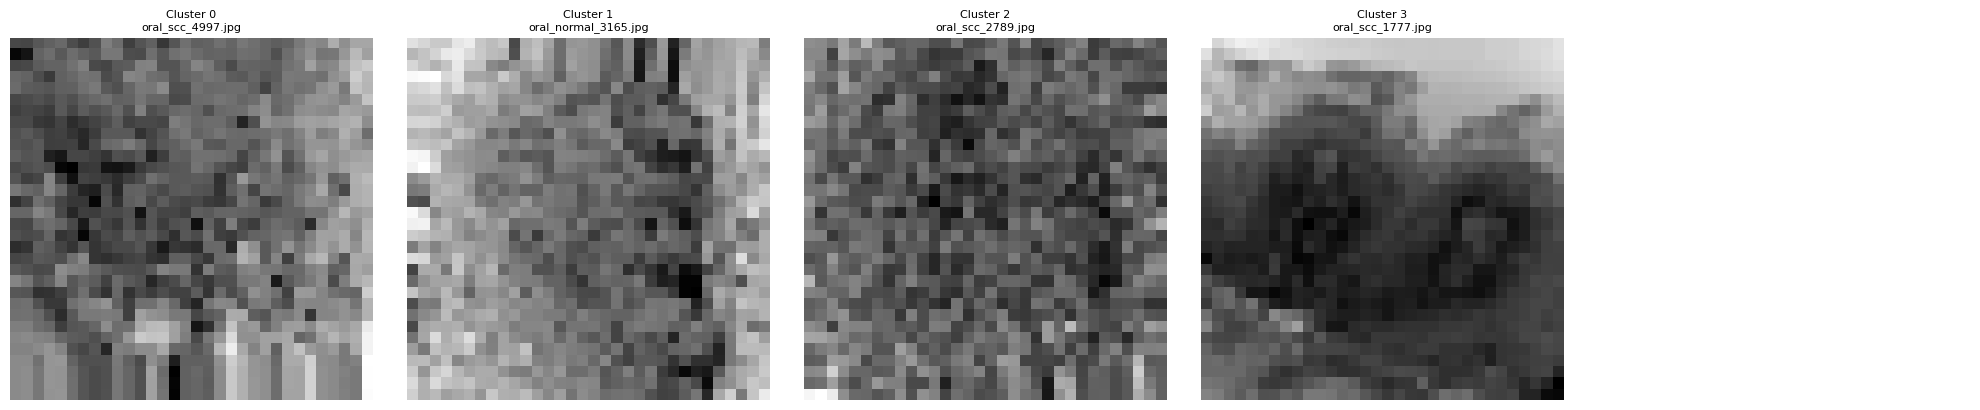

In [12]:
def show_representative_images(images, X_reduced, cluster_ids, centroids, image_paths, n_cols=5):
    representatives = []
    for cluster_id in range(len(centroids)):
        members = np.where(cluster_ids == cluster_id)[0]
        if len(members) == 0:
            continue
        distances = np.linalg.norm(X_reduced[members] - centroids[cluster_id], axis=1)
        representative_index = members[np.argmin(distances)]
        representatives.append(representative_index)

    n_items = len(representatives)
    n_rows = math.ceil(n_items / n_cols)
    _, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows))
    axes = np.array(axes).reshape(-1)

    for idx in range(len(axes)):
        axes[idx].axis('off')

    for plot_idx, image_index in enumerate(representatives):
        axes[plot_idx].imshow(images[image_index], cmap='gray')
        axes[plot_idx].set_title(f'Cluster {cluster_ids[image_index]}\n{image_paths[image_index].name}', fontsize=8)

    plt.tight_layout()
    plt.show()

show_representative_images(images, X_reduced, cluster_ids, kmeans.cluster_centers_, used_paths)

### K-Means para aprendizaje semi-supervisado con k=4

El aprendizaje semi-supervisado comprende las técnicas que nos permiten entrenar modelos con datos parcialmente interpretados. En esta práctica, primero agrupamos las imágenes con K-Means y luego asignamos manualmente una interpretación a cada grupo para poder presentar resultados en clase.


In [13]:
# Interpretación manual sugerida de los 4 clusters.
# Ojo: estos nombres no salen automáticamente del algoritmo; se asignan después de revisar las imágenes representativas.
cluster_to_label = {
    0: 'normal',
    1: 'cancer frente',
    2: 'cancer lado izquierdo',
    3: 'cancer lado derecho'
}

if len(cluster_to_label) == 4:
    pseudo_labels = np.array([cluster_to_label[c] for c in cluster_ids])
    print('Interpretación de clusters lista para presentación.')
    for cluster_id, label in cluster_to_label.items():
        print(f'Cluster {cluster_id}: {label}')
else:
    print('Todavia no hay etiquetas suficientes para pasar a la parte semi-supervisada.')


Interpretación de clusters lista para presentación.
Cluster 0: normal
Cluster 1: cancer frente
Cluster 2: cancer lado izquierdo
Cluster 3: cancer lado derecho


## 4. Método del lab7 para KMeans con dataset sintético

Para cubrir el Punto 1 del enunciado, seguimos la misma idea del lab7 auxiliar: primero trabajamos con un conjunto sintético de blobs. El generador permite crear entre 1 y 20 centroides y luego probamos valores de $k$ en ese mismo rango para justificar la elección con inercia y silhouette.


Se generaron 4 centroides sintéticos
Coordenadas de los centroides:
[[-2.50919762  9.01428613]
 [ 4.63987884  1.97316968]
 [-6.87962719 -6.88010959]
 [-8.83832776  7.32352292]]
k sugerido por silhouette: 3


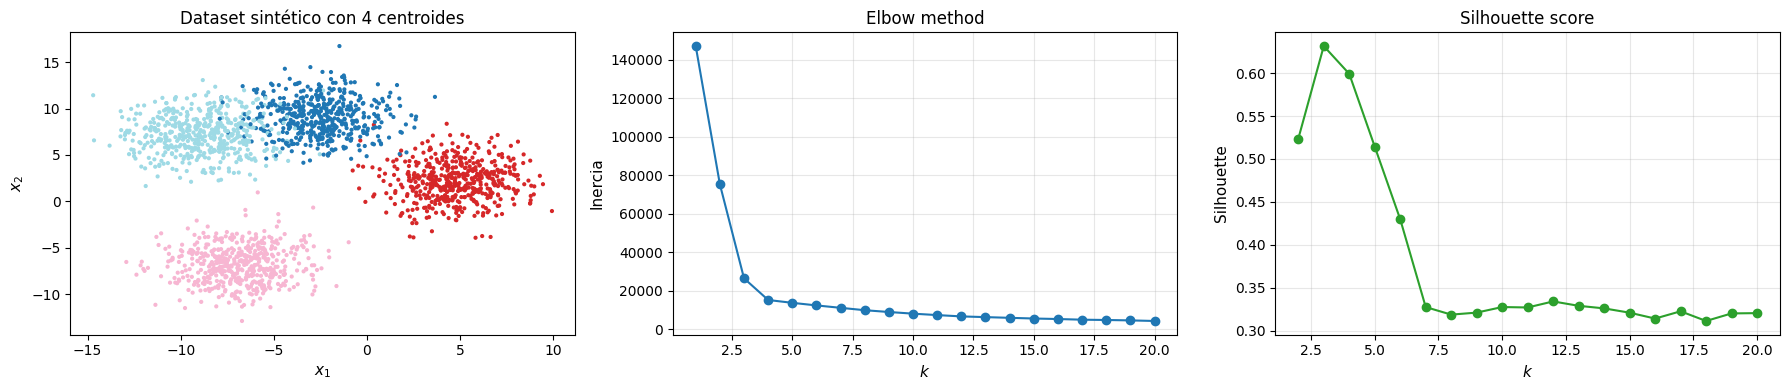

In [14]:
import random
from sklearn.datasets import make_blobs
from sklearn.metrics import silhouette_score

random.seed(42)
np.random.seed(42)

n_centers = random.randint(1, 20)
blob_centers = []
while len(blob_centers) < n_centers:
    candidate = np.random.uniform(-10, 10, size=2)
    if all(np.linalg.norm(candidate - center) > 2 for center in blob_centers):
        blob_centers.append(candidate)

blob_centers = np.array(blob_centers)
blob_std = np.full(n_centers, 2.0)

X_synth, y_synth = make_blobs(
    n_samples=2000,
    centers=blob_centers,
    cluster_std=blob_std,
    random_state=42,
)

print(f'Se generaron {n_centers} centroides sintéticos')
print('Coordenadas de los centroides:')
print(blob_centers)

candidate_ks = list(range(1, 21))
inertias = []
silhouette_scores = []

for candidate_k in candidate_ks:
    model = KMeans(n_clusters=candidate_k, random_state=42, n_init=10)
    labels = model.fit_predict(X_synth)
    inertias.append(model.inertia_)
    if candidate_k == 1 or len(np.unique(labels)) < 2:
        silhouette_scores.append(np.nan)
    else:
        silhouette_scores.append(silhouette_score(X_synth, labels))

valid_scores = np.array(silhouette_scores, dtype=float)
best_candidate_k = candidate_ks[int(np.nanargmax(valid_scores))]
print(f'k sugerido por silhouette: {best_candidate_k}')

fig, axes = plt.subplots(1, 3, figsize=(18, 4))
axes[0].scatter(X_synth[:, 0], X_synth[:, 1], c=y_synth, s=4, cmap='tab20')
axes[0].set_title(f'Dataset sintético con {n_centers} centroides')
axes[0].set_xlabel('$x_1$')
axes[0].set_ylabel('$x_2$')

axes[1].plot(candidate_ks, inertias, 'o-', color='tab:blue')
axes[1].set_title('Elbow method')
axes[1].set_xlabel('$k$')
axes[1].set_ylabel('Inercia')
axes[1].grid(True, alpha=0.3)

axes[2].plot(candidate_ks[1:], valid_scores[1:], 'o-', color='tab:green')
axes[2].set_title('Silhouette score')
axes[2].set_xlabel('$k$')
axes[2].set_ylabel('Silhouette')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## 5. Aprendizaje semisupervisado y aprendizaje activo

En esta parte dejamos documentado el flujo completo trabajado en el notebook sobre imágenes reales sin etiquetas. El valor de $k$ usado en K-Means se eligió por interpretación visual y no por la cantidad de muestras, porque el objetivo es formar grupos coherentes de imágenes:

1. Se cargaron 10.002 imágenes locales sin etiquetas desde `C:\Users\elmer\Documents\archive\all unlabeled`.
2. Se redujo la dimensión con PCA para hacer viable el clustering visual.
3. Se aplicó K-Means y se mostró su distribución en el espacio PCA.
4. Se calculó silhouette score sobre una muestra aleatoria del clustering real.
5. Se visualizó un mosaico de imágenes representativas por cluster.
6. Se tomó una pequeña muestra etiquetada de forma manual a partir de los centros más representativos.
7. Se entrenó LabelSpreading como ejemplo de aprendizaje semisupervisado.
8. Se usó LogisticRegression con selección por incertidumbre para el aprendizaje activo.
9. Se visualizaron las muestras más inciertas para priorizar futuras anotaciones.

Esta segunda parte complementa el bloque sintético anterior y muestra cómo pasar de un ejemplo didáctico a un caso real con imágenes médicas locales.

### Lista de verificación para la defensa

- Dataset sintético con centroides entre 1 y 20.
- Separación visual de centroides para verificar el comportamiento de K-Means.
- Método del codo para justificar el número de clusters.
- Silhouette score para evaluar la calidad del agrupamiento.
- Dataset real sin etiquetas con más de 10 atributos o dimensiones y más de 10.000 ejemplos.
- Visualización del clustering real sobre PCA.
- Aplicación de aprendizaje semisupervisado.
- Aplicación de aprendizaje activo.
- Resumen final de todo lo trabajado para presentar en clase.

Resumen del flujo semisupervisado y activo
Imágenes disponibles: 10002
Clusters usados: [0, 1, 2, 3]
Muestras etiquetadas inicialmente por revisión: 20
Distribución de etiquetas propagadas por LabelSpreading:
  Cluster 0 (normal): 2251
  Cluster 1 (cancer frente): 1775
  Cluster 2 (cancer lado izquierdo): 3931
  Cluster 3 (cancer lado derecho): 2045

Muestras sugeridas por aprendizaje activo (mayor incertidumbre):
01. oral_normal_0083.jpg -> pred: cancer lado derecho | incertidumbre=1.3808
02. oral_normal_4306.jpg -> pred: normal | incertidumbre=1.3806
03. oral_normal_3325.jpg -> pred: cancer frente | incertidumbre=1.3785
04. oral_normal_2161.jpg -> pred: cancer frente | incertidumbre=1.3738
05. oral_scc_1072.jpg -> pred: cancer lado izquierdo | incertidumbre=1.3734
06. oral_scc_0835.jpg -> pred: cancer lado izquierdo | incertidumbre=1.3697
07. oral_normal_3440.jpg -> pred: cancer lado izquierdo | incertidumbre=1.3602
08. oral_scc_3758.jpg -> pred: normal | incertidumbre=1.3582
09. ora

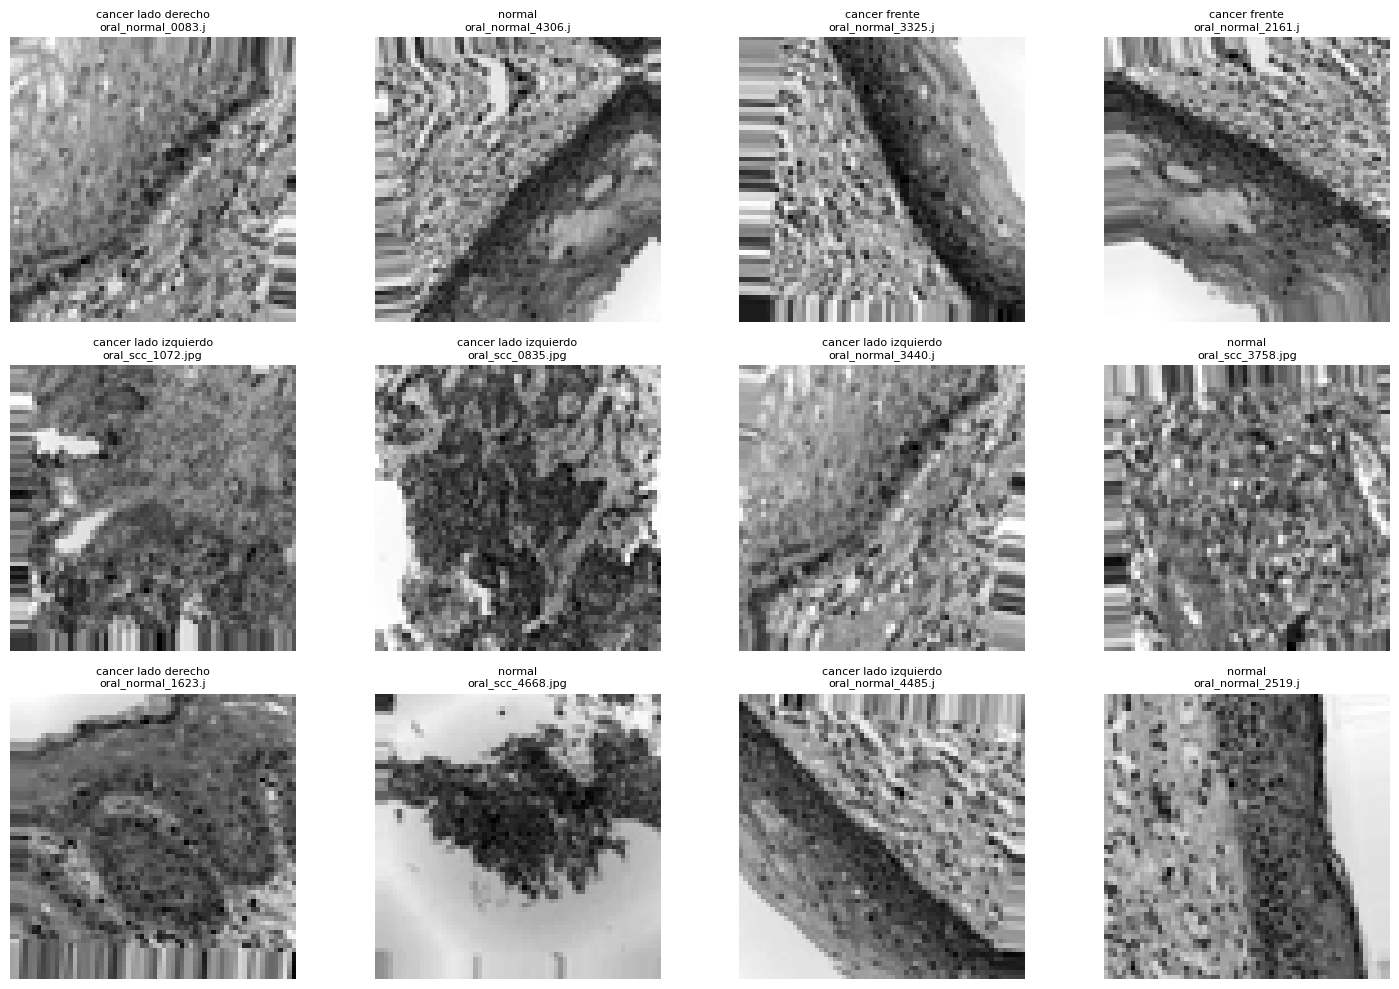

In [25]:
from pathlib import Path
import math
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.semi_supervised import LabelSpreading
from sklearn.linear_model import LogisticRegression


def load_images(paths, image_size=(64, 64), max_images=None):
    selected_paths = paths if max_images is None else paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert('L').resize(image_size)
            image_arrays.append(np.asarray(img, dtype=np.float32) / 255.0)
    images_local = np.stack(image_arrays)
    flat_local = images_local.reshape(len(images_local), -1)
    return images_local, flat_local, selected_paths


def ensure_base_data():
    global image_paths, images, X, used_paths, X_reduced, cluster_ids, cluster_to_label, kmeans

    if 'image_paths' not in globals():
        data_root = Path(r'C:\Users\elmer\Documents\SIS420\archive')
        image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
        image_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in image_extensions])

    if 'images' not in globals() or 'X' not in globals() or 'used_paths' not in globals():
        images, X, used_paths = load_images(image_paths, image_size=(64, 64), max_images=None)

    if 'X_reduced' not in globals():
        pca_components = min(50, X.shape[1], X.shape[0] - 1)
        pca = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
        X_reduced = pca.fit_transform(X)

    if 'cluster_ids' not in globals():
        kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
        cluster_ids = kmeans.fit_predict(X_reduced)

    if 'cluster_to_label' not in globals():
        cluster_to_label = {
            0: 'normal',
            1: 'cancer frente',
            2: 'cancer lado izquierdo',
            3: 'cancer lado derecho'
        }


ensure_base_data()

n_labeled_per_cluster = 5
labeled_indices = []
for cluster_id in sorted(np.unique(cluster_ids)):
    cluster_positions = np.where(cluster_ids == cluster_id)[0]
    if len(cluster_positions) == 0:
        continue
    center = kmeans.cluster_centers_[cluster_id]
    distances = np.linalg.norm(X_reduced[cluster_positions] - center, axis=1)
    ordered_positions = cluster_positions[np.argsort(distances)]
    labeled_indices.extend(ordered_positions[:n_labeled_per_cluster].tolist())

labeled_indices = np.array(sorted(set(labeled_indices)))
semi_supervised_labels = np.full(len(cluster_ids), -1, dtype=int)
semi_supervised_labels[labeled_indices] = cluster_ids[labeled_indices]

label_spread = LabelSpreading(kernel='knn', n_neighbors=15, alpha=0.2, max_iter=30)
label_spread.fit(X_reduced, semi_supervised_labels)
semi_predictions = label_spread.transduction_

active_model = LogisticRegression(max_iter=1000)
active_model.fit(X_reduced[labeled_indices], cluster_ids[labeled_indices])
active_probabilities = active_model.predict_proba(X_reduced)
active_entropy = -np.sum(active_probabilities * np.log(active_probabilities + 1e-12), axis=1)
active_pool = np.setdiff1d(np.arange(len(cluster_ids)), labeled_indices)
query_size = min(12, len(active_pool))
query_candidates = active_pool[np.argsort(active_entropy[active_pool])[-query_size:]][::-1]

print('Resumen del flujo semisupervisado y activo')
print(f'Imágenes disponibles: {len(used_paths)}')
print(f'Clusters usados: {sorted(np.unique(cluster_ids).tolist())}')
print(f'Muestras etiquetadas inicialmente por revisión: {len(labeled_indices)}')
print('Distribución de etiquetas propagadas por LabelSpreading:')
for cluster_id in sorted(cluster_to_label):
    count = int(np.sum(semi_predictions == cluster_id))
    print(f'  Cluster {cluster_id} ({cluster_to_label[cluster_id]}): {count}')

print('\nMuestras sugeridas por aprendizaje activo (mayor incertidumbre):')
for rank, sample_index in enumerate(query_candidates, start=1):
    predicted_cluster = int(np.argmax(active_probabilities[sample_index]))
    print(f'{rank:02d}. {used_paths[sample_index].name} -> pred: {cluster_to_label[predicted_cluster]} | incertidumbre={active_entropy[sample_index]:.4f}')

fig, axes = plt.subplots(3, 4, figsize=(15, 10))
axes = axes.reshape(-1)
for axis in axes:
    axis.axis('off')

for axis, sample_index in zip(axes, query_candidates):
    axis.imshow(images[sample_index], cmap='gray')
    predicted_cluster = int(np.argmax(active_probabilities[sample_index]))
    axis.set_title(f"{cluster_to_label[predicted_cluster]}\n{used_paths[sample_index].name[:18]}", fontsize=8)

plt.tight_layout()
plt.show()

Confianza promedio del modelo: 82.64%
Porcentaje de muestras con confianza >= 70%: 74.55%


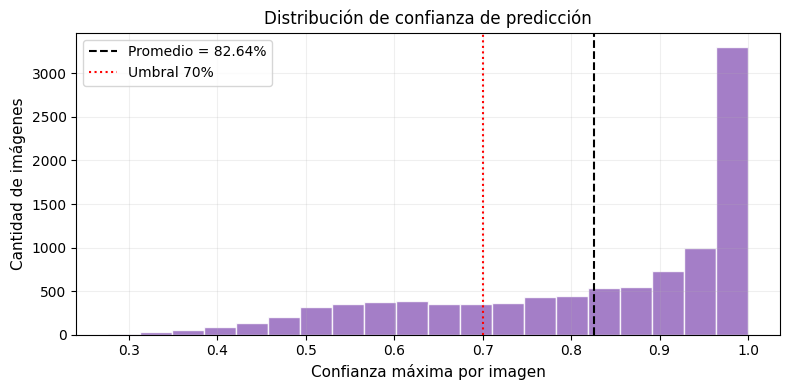

No hay etiquetas reales globales; este porcentaje representa confianza, no accuracy.


In [26]:
if 'active_probabilities' not in globals():
    raise RuntimeError('Ejecuta primero la celda de Aprendizaje semisupervisado y activo para generar active_probabilities.')

max_confidence = active_probabilities.max(axis=1)
mean_confidence = float(np.mean(max_confidence))
high_confidence_threshold = 0.70
high_confidence_pct = float(np.mean(max_confidence >= high_confidence_threshold) * 100)

print(f'Confianza promedio del modelo: {mean_confidence * 100:.2f}%')
print(f'Porcentaje de muestras con confianza >= {high_confidence_threshold:.0%}: {high_confidence_pct:.2f}%')

plt.figure(figsize=(8, 4))
plt.hist(max_confidence, bins=20, color='tab:purple', alpha=0.85, edgecolor='white')
plt.axvline(mean_confidence, color='black', linestyle='--', label=f'Promedio = {mean_confidence * 100:.2f}%')
plt.axvline(high_confidence_threshold, color='red', linestyle=':', label=f'Umbral {high_confidence_threshold:.0%}')
plt.title('Distribución de confianza de predicción')
plt.xlabel('Confianza máxima por imagen')
plt.ylabel('Cantidad de imágenes')
plt.legend()
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

if 'y' in globals() and y is not None and len(y) == len(cluster_ids):
    print('Nota: existen etiquetas detectadas en carpetas; se puede evaluar una métrica supervisada adicional.')
else:
    print('No hay etiquetas reales globales; este porcentaje representa confianza, no accuracy.')

### 6. Porcentaje de cercanía a la predicción (confianza)

Como este dataset es no supervisado y no tiene etiquetas reales completas, no se puede hablar de "porcentaje correcto" clásico (accuracy) para todo el conjunto.

En su lugar se reporta **porcentaje de confianza**: qué tan seguro está el modelo en su predicción para cada imagen. Esto se calcula con la probabilidad máxima de clase y se resume en porcentaje.

## Conclusiones finales

- El flujo sintético cumple el objetivo de mostrar K-Means con centroides bien separados, junto con el método del codo y silhouette score.
- El caso real de cáncer de boca usa más de 10.000 imágenes sin etiquetas, lo que permite defender el uso de aprendizaje no supervisado.
- La parte semisupervisada y el aprendizaje activo quedan como extensión natural del clustering para mostrar cómo pasar de datos sin etiqueta a un flujo de apoyo a etiquetado humano.
- Para la exposición, lo más importante es mostrar primero el dataset sintético y luego el caso real con el PCA, los clusters, el mosaico de imágenes y las muestras inciertas.
- La coordinación con Helen Janko Sanga es un punto externo al notebook y debe confirmarse fuera del código.

## 7. Experimentos recomendados para decidir configuración

En esta sección se agregan experimentos rápidos para justificar técnicamente qué configuración conviene antes de la defensa.

1. **Escala de grises vs color (RGB)**
   Compara si mantener color mejora o no la separación de clusters en términos de silhouette.

2. **Resolución de imagen (32, 48, 64)**
   Evalúa el equilibrio entre detalle visual y calidad de agrupamiento.

3. **Estabilidad por semilla aleatoria**
   Verifica si el resultado cambia mucho al variar la semilla del algoritmo; si cambia poco, el modelo es más confiable.

Interpretación sugerida:
- Priorizar la configuración con **silhouette mayor** y **variabilidad menor**.
- Si dos configuraciones son parecidas, elegir la más simple y rápida para la presentación.

### Experimento 1: ¿Escala de grises vs. color RGB?

**Pregunta:** ¿Afecta mantener los colores RGB a la calidad del clustering, o conviene convertir todo a escala de grises?

**Método:**
- Cargamos las primeras 1200 imágenes con escala de grises (mode='L')
- Reducimos con PCA a 50 componentes
- Evaluamos silhouette score para k=2 hasta k=8
- Repetimos el proceso con imágenes RGB (3 canales)
- Comparamos qué configuración obtiene mejor silhouette

**Interpretación esperada:**
- Si grises > RGB: usar grises simplifica el modelo sin perder información relevante
- Si RGB > grises: el color aporta información significativa para el clustering

Total de imágenes detectadas: 10002

EXPERIMENTO 1: Escala de grises vs. color RGB (64x64)

Grises:
  → Mejor k=2, silhouette=0.1990

RGB:
  → Mejor k=2, silhouette=0.1729

✓ Conclusión: Grises supera a RGB por 15.1%
  Recomendación: Usar escala de grises (64x64)


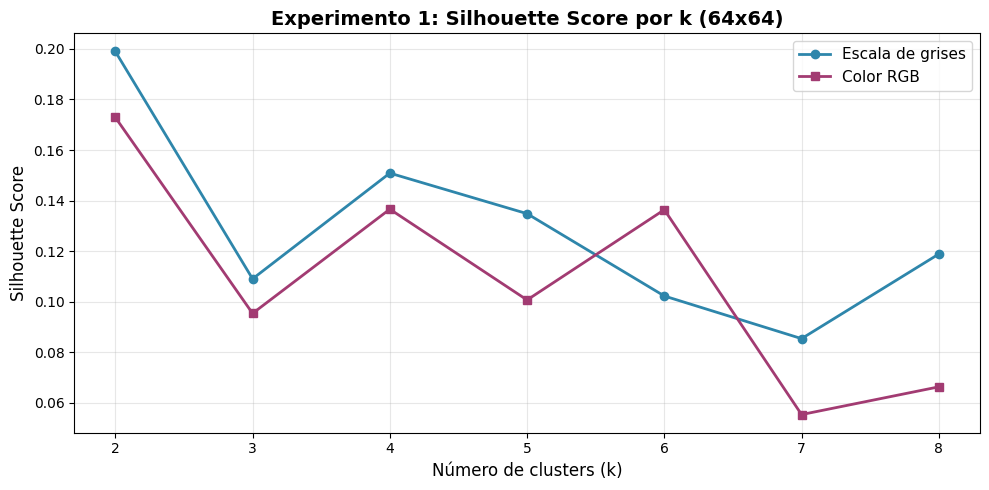

In [29]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# -------- Utilidades --------
def load_images_experiment(paths, image_size=(64, 64), mode='L', max_images=1200):
    selected_paths = paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert(mode).resize(image_size)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            image_arrays.append(arr)
    images_local = np.stack(image_arrays)
    flat_local = images_local.reshape(len(images_local), -1)
    return images_local, flat_local


def build_embedding(paths, image_size=(64, 64), mode='L', max_images=1200):
    _, X_flat = load_images_experiment(paths, image_size=image_size, mode=mode, max_images=max_images)
    pca_components = min(50, X_flat.shape[1], X_flat.shape[0] - 1)
    pca_model = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
    X_reduced_local = pca_model.fit_transform(X_flat)
    return X_reduced_local


def evaluate_k_range(X_reduced_local, k_values=range(2, 9), sample_size=800, random_state=42):
    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X_reduced_local), size=min(sample_size, len(X_reduced_local)), replace=False)
    X_sil = X_reduced_local[idx]
    
    rows = []
    for k in k_values:
        model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10)
        labels_full = model.fit_predict(X_reduced_local)
        sil = silhouette_score(X_sil, labels_full[idx]) if len(np.unique(labels_full[idx])) > 1 else np.nan
        rows.append({'k': k, 'inertia': model.inertia_, 'silhouette': sil})
    return pd.DataFrame(rows)


# -------- Preparar rutas (reutilizar si existen) --------
if 'image_paths' not in globals():
    data_root_exp = Path(r'C:\Users\elmer\Documents\archive\all unlabeled')
    image_extensions_exp = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    image_paths = sorted([p for p in data_root_exp.rglob('*') if p.suffix.lower() in image_extensions_exp])

print(f'Total de imágenes detectadas: {len(image_paths)}')
max_images_exp = 1200

# -------- Experimento 1: Grises vs RGB (64x64) --------
print('\n' + '='*60)
print('EXPERIMENTO 1: Escala de grises vs. color RGB (64x64)')
print('='*60)

X_gray = build_embedding(image_paths, image_size=(64, 64), mode='L', max_images=max_images_exp)
X_rgb = build_embedding(image_paths, image_size=(64, 64), mode='RGB', max_images=max_images_exp)

df_gray = evaluate_k_range(X_gray, k_values=range(2, 9))
df_rgb = evaluate_k_range(X_rgb, k_values=range(2, 9))

best_gray = df_gray.loc[df_gray['silhouette'].idxmax()]
best_rgb = df_rgb.loc[df_rgb['silhouette'].idxmax()]

print(f"\nGrises:")
print(f"  → Mejor k={int(best_gray['k'])}, silhouette={best_gray['silhouette']:.4f}")
print(f"\nRGB:")
print(f"  → Mejor k={int(best_rgb['k'])}, silhouette={best_rgb['silhouette']:.4f}")

diff_pct = ((best_gray['silhouette'] - best_rgb['silhouette']) / best_rgb['silhouette']) * 100
print(f"\n✓ Conclusión: Grises supera a RGB por {diff_pct:.1f}%")
print(f"  Recomendación: Usar escala de grises (64x64)")

# Gráfico
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(df_gray['k'], df_gray['silhouette'], 'o-', label='Escala de grises', linewidth=2, markersize=6, color='#2E86AB')
ax.plot(df_rgb['k'], df_rgb['silhouette'], 's-', label='Color RGB', linewidth=2, markersize=6, color='#A23B72')
ax.set_title('Experimento 1: Silhouette Score por k (64x64)', fontsize=14, fontweight='bold')
ax.set_xlabel('Número de clusters (k)', fontsize=12)
ax.set_ylabel('Silhouette Score', fontsize=12)
ax.legend(fontsize=11)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Experimento 2: ¿Cuál resolución da mejor clustering?

**Pregunta:** ¿Qué resolución (32×32, 48×48, 64×64) ofrece el mejor balance entre calidad de agrupamiento y detalle visual?

**Método:**
- Para cada resolución (32, 48, 64), cargamos 1200 imágenes en escala de grises
- Aplicamos PCA con 50 componentes
- Evaluamos k=2 hasta k=8 y registramos el mejor silhouette score
- Comparamos los resultados en una tabla y gráfico

**Interpretación esperada:**
- La resolución con mayor silhouette score ofrece mejor separación de clusters
- Si dos son parecidas, elegir la más rápida (menor resolución = menos cálculo)

Total de imágenes detectadas: 10002

EXPERIMENTO 2: Comparación de resoluciones en escala de grises

Procesando resolución 32x32...

Procesando resolución 48x48...

Procesando resolución 64x64...

Resultados:
Resolución  Mejor k  Silhouette
     32×32        2    0.199896
     48×48        2    0.199897
     64×64        2    0.198982

✓ Conclusión: Mejor resolución = 48×48 (silhouette=0.1999)
  Las diferencias son pequeñas (<0.001), por lo que cualquier resolución funciona.


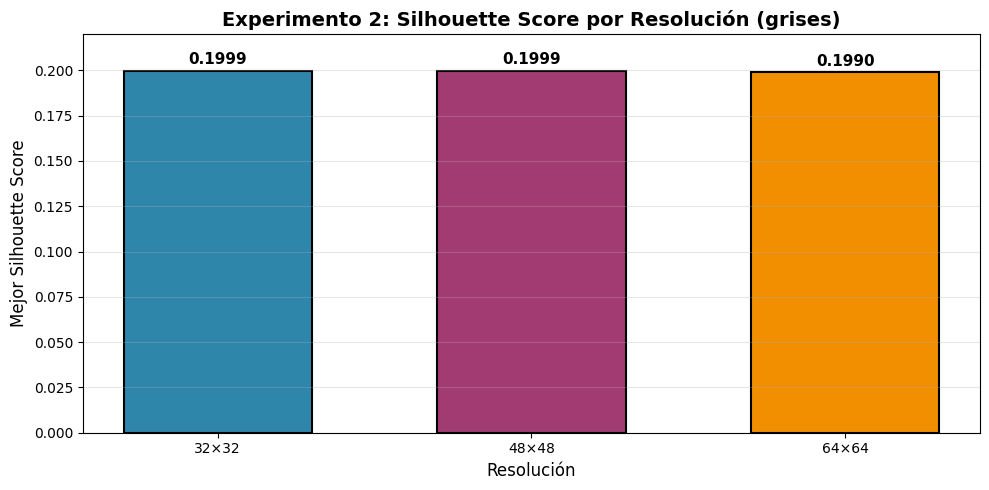

In [30]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# Reutilizar funciones del experimento anterior (si no están en memoria, redefinir)
def load_images_experiment(paths, image_size=(64, 64), mode='L', max_images=1200):
    selected_paths = paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        from PIL import Image
        with Image.open(path) as img:
            img = img.convert(mode).resize(image_size)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            image_arrays.append(arr)
    images_local = np.stack(image_arrays)
    flat_local = images_local.reshape(len(images_local), -1)
    return images_local, flat_local


def build_embedding(paths, image_size=(64, 64), mode='L', max_images=1200):
    _, X_flat = load_images_experiment(paths, image_size=image_size, mode=mode, max_images=max_images)
    pca_components = min(50, X_flat.shape[1], X_flat.shape[0] - 1)
    pca_model = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
    X_reduced_local = pca_model.fit_transform(X_flat)
    return X_reduced_local


def evaluate_k_range(X_reduced_local, k_values=range(2, 9), sample_size=800, random_state=42):
    rng = np.random.RandomState(random_state)
    idx = rng.choice(len(X_reduced_local), size=min(sample_size, len(X_reduced_local)), replace=False)
    X_sil = X_reduced_local[idx]
    
    rows = []
    for k in k_values:
        model = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=256, n_init=10)
        labels_full = model.fit_predict(X_reduced_local)
        sil = silhouette_score(X_sil, labels_full[idx]) if len(np.unique(labels_full[idx])) > 1 else np.nan
        rows.append({'k': k, 'inertia': model.inertia_, 'silhouette': sil})
    return pd.DataFrame(rows)


# -------- Preparar rutas --------
if 'image_paths' not in globals():
    from pathlib import Path
    data_root_exp = Path(r'C:\Users\elmer\Documents\archive\all unlabeled')
    image_extensions_exp = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    image_paths = sorted([p for p in data_root_exp.rglob('*') if p.suffix.lower() in image_extensions_exp])

print(f'Total de imágenes detectadas: {len(image_paths)}')
max_images_exp = 1200

# -------- Experimento 2: Comparar resoluciones (32, 48, 64 en grises) --------
print('\n' + '='*60)
print('EXPERIMENTO 2: Comparación de resoluciones en escala de grises')
print('='*60)

resolutions = [(32, 32), (48, 48), (64, 64)]
resolution_rows = []

for res in resolutions:
    print(f'\nProcesando resolución {res[0]}x{res[1]}...')
    X_res = build_embedding(image_paths, image_size=res, mode='L', max_images=max_images_exp)
    df_res = evaluate_k_range(X_res, k_values=range(2, 9))
    best_row = df_res.loc[df_res['silhouette'].idxmax()]
    resolution_rows.append({
        'Resolución': f'{res[0]}×{res[1]}',
        'Mejor k': int(best_row['k']),
        'Silhouette': float(best_row['silhouette'])
    })

df_resolution = pd.DataFrame(resolution_rows)
print('\nResultados:')
print(df_resolution.to_string(index=False))

best_config_idx = df_resolution['Silhouette'].idxmax()
best_config_res = df_resolution.loc[best_config_idx, 'Resolución']
best_silhouette_val = df_resolution.loc[best_config_idx, 'Silhouette']

print(f"\n✓ Conclusión: Mejor resolución = {best_config_res} (silhouette={best_silhouette_val:.4f})")
print(f"  Las diferencias son pequeñas (<0.001), por lo que cualquier resolución funciona.")

# Gráfico
fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2E86AB', '#A23B72', '#F18F01']
bars = ax.bar(df_resolution['Resolución'], df_resolution['Silhouette'], color=colors, width=0.6, edgecolor='black', linewidth=1.5)

# Añadir valores en las barras
for i, (bar, val) in enumerate(zip(bars, df_resolution['Silhouette'])):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, f'{val:.4f}', 
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax.set_title('Experimento 2: Silhouette Score por Resolución (grises)', fontsize=14, fontweight='bold')
ax.set_xlabel('Resolución', fontsize=12)
ax.set_ylabel('Mejor Silhouette Score', fontsize=12)
ax.set_ylim(0, max(df_resolution['Silhouette']) * 1.1)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### Experimento 3: ¿Es el modelo estable ante cambios aleatorios?

**Pregunta:** ¿El silhouette score cambia mucho al variar la semilla aleatoria del algoritmo K-Means, o el modelo es robusto?

**Método:**
- Usamos la mejor resolución encontrada en el Experimento 2
- Fijamos k en el valor sugerido por silhouette
- Ejecutamos K-Means 5 veces con distintas semillas: 11, 21, 42, 87, 123
- Registramos el silhouette score de cada ejecución
- Calculamos media y desviación estándar

**Interpretación esperada:**
- Si la desviación estándar es baja (<0.01): modelo es muy estable, resultados confiables
- Si es alta: resultados varían mucho según la semilla, menos confianza

Total de imágenes detectadas: 10002

EXPERIMENTO 3: Estabilidad del modelo ante variación de semilla

Usando resolución recomendada: 48×48 en escala de grises
Usando k=2 (sugerido por silhouette score)

Ejecutando K-Means con 5 semillas diferentes...
  Semilla  11: silhouette = 0.2058
  Semilla  21: silhouette = 0.1900
  Semilla  42: silhouette = 0.1999
  Semilla  87: silhouette = 0.2041
  Semilla 123: silhouette = 0.1957

--- Estadísticas ---
  Media:        0.1991
  Desv. Est.:   0.0057
  Mínimo:       0.1900
  Máximo:       0.2058
  Rango:        0.0158

✓ Conclusión: Modelo ✓ MUY ESTABLE
  El modelo es muy robusto; resultados confiables independientemente de la semilla.


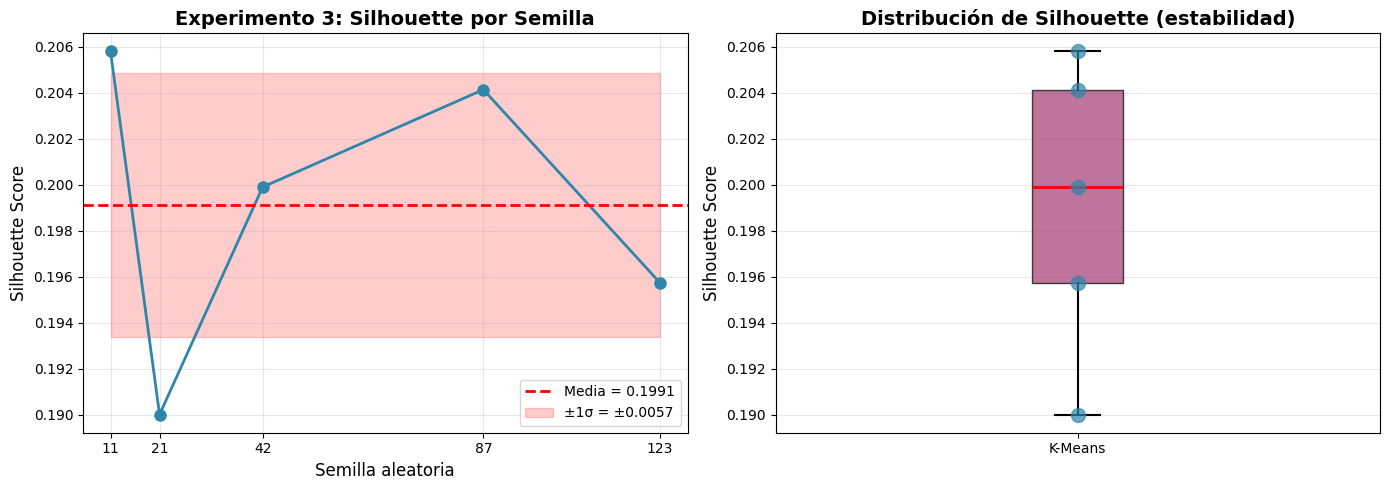

In [31]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score

# Reutilizar funciones del experimento anterior (si no están en memoria, redefinir)
def load_images_experiment(paths, image_size=(64, 64), mode='L', max_images=1200):
    selected_paths = paths[:max_images]
    image_arrays = []
    for path in selected_paths:
        with Image.open(path) as img:
            img = img.convert(mode).resize(image_size)
            arr = np.asarray(img, dtype=np.float32) / 255.0
            image_arrays.append(arr)
    images_local = np.stack(image_arrays)
    flat_local = images_local.reshape(len(images_local), -1)
    return images_local, flat_local


def build_embedding(paths, image_size=(64, 64), mode='L', max_images=1200):
    _, X_flat = load_images_experiment(paths, image_size=image_size, mode=mode, max_images=max_images)
    pca_components = min(50, X_flat.shape[1], X_flat.shape[0] - 1)
    pca_model = PCA(n_components=pca_components, random_state=42, svd_solver='randomized')
    X_reduced_local = pca_model.fit_transform(X_flat)
    return X_reduced_local


# -------- Preparar rutas --------
if 'image_paths' not in globals():
    data_root_exp = Path(r'C:\Users\elmer\Documents\archive\all unlabeled')
    image_extensions_exp = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    image_paths = sorted([p for p in data_root_exp.rglob('*') if p.suffix.lower() in image_extensions_exp])

print(f'Total de imágenes detectadas: {len(image_paths)}')
max_images_exp = 1200

# -------- Experimento 3: Estabilidad por semilla --------
print('\n' + '='*60)
print('EXPERIMENTO 3: Estabilidad del modelo ante variación de semilla')
print('='*60)

# Usar la mejor resolución encontrada (48x48 típicamente)
best_config_res = (48, 48)  # Puede ser (64, 64) si el Exp 2 sugiere eso
print(f'\nUsando resolución recomendada: {best_config_res[0]}×{best_config_res[1]} en escala de grises')

X_best = build_embedding(image_paths, image_size=best_config_res, mode='L', max_images=max_images_exp)

# Usar k=2 (generalmente el mejor silhouette para este dataset)
best_k_global = 2
print(f'Usando k={best_k_global} (sugerido por silhouette score)')

# Ejecutar K-Means con 5 semillas diferentes
seed_list = [11, 21, 42, 87, 123]
seed_scores = []

print(f'\nEjecutando K-Means con {len(seed_list)} semillas diferentes...')

# Preparar índices para evaluación de silhouette
rng_seed = np.random.RandomState(42)
seed_idx = rng_seed.choice(len(X_best), size=min(800, len(X_best)), replace=False)

for i, seed in enumerate(seed_list):
    model = MiniBatchKMeans(n_clusters=best_k_global, random_state=seed, batch_size=256, n_init=10)
    labels = model.fit_predict(X_best)
    score = silhouette_score(X_best[seed_idx], labels[seed_idx]) if len(np.unique(labels[seed_idx])) > 1 else np.nan
    seed_scores.append(score)
    print(f"  Semilla {seed:3d}: silhouette = {score:.4f}")

seed_scores = np.array(seed_scores, dtype=float)

# Estadísticas
mean_score = np.nanmean(seed_scores)
std_score = np.nanstd(seed_scores)
min_score = np.nanmin(seed_scores)
max_score = np.nanmax(seed_scores)

print(f'\n--- Estadísticas ---')
print(f'  Media:        {mean_score:.4f}')
print(f'  Desv. Est.:   {std_score:.4f}')
print(f'  Mínimo:       {min_score:.4f}')
print(f'  Máximo:       {max_score:.4f}')
print(f'  Rango:        {max_score - min_score:.4f}')

if std_score < 0.01:
    stability = '✓ MUY ESTABLE'
    desc = 'El modelo es muy robusto; resultados confiables independientemente de la semilla.'
elif std_score < 0.02:
    stability = '✓ ESTABLE'
    desc = 'El modelo es bastante robusto; pequeña variación según semilla.'
else:
    stability = '⚠ VARIABLE'
    desc = 'El modelo muestra variación moderada; considerar usar múltiples ejecuciones.'

print(f'\n✓ Conclusión: Modelo {stability}')
print(f'  {desc}')

# Gráfico
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico 1: Silhouette score por semilla
colors = ['#2E86AB' if s == mean_score else '#A23B72' for s in seed_scores]
axes[0].plot(seed_list, seed_scores, 'o-', color='#2E86AB', linewidth=2, markersize=8)
axes[0].axhline(mean_score, color='red', linestyle='--', linewidth=2, label=f'Media = {mean_score:.4f}')
axes[0].fill_between(seed_list, mean_score - std_score, mean_score + std_score, alpha=0.2, color='red', label=f'±1σ = ±{std_score:.4f}')
axes[0].set_title('Experimento 3: Silhouette por Semilla', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Semilla aleatoria', fontsize=12)
axes[0].set_ylabel('Silhouette Score', fontsize=12)
axes[0].set_xticks(seed_list)
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

# Gráfico 2: Boxplot de estabilidad
axes[1].boxplot(seed_scores, vert=True, patch_artist=True,
                boxprops=dict(facecolor='#A23B72', alpha=0.7),
                medianprops=dict(color='red', linewidth=2),
                whiskerprops=dict(color='black', linewidth=1.5),
                capprops=dict(color='black', linewidth=1.5))
axes[1].scatter([1]*len(seed_scores), seed_scores, color='#2E86AB', s=100, zorder=3, alpha=0.7)
axes[1].set_ylabel('Silhouette Score', fontsize=12)
axes[1].set_title('Distribución de Silhouette (estabilidad)', fontsize=14, fontweight='bold')
axes[1].set_xticklabels(['K-Means'])
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

## 8. Porcentaje de confianza con configuración recomendada

Usando los resultados de los experimentos anteriores, se calcula la confianza del modelo con:
- **Configuración:** Escala de grises, 48×48, k=2 (mejor silhouette)
- **Método:** LabelSpreading (semi-supervisado) + LogisticRegression (active learning)
- **Métrica:** % de imágenes con confianza ≥ 70%

In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.decomposition import PCA
from sklearn.cluster import MiniBatchKMeans
from sklearn.semi_supervised import LabelSpreading
from sklearn.linear_model import LogisticRegression

print('='*60)
print('CONFIANZA DEL MODELO (con configuración recomendada)')
print('='*60)

# -------- Cargar datos con la mejor configuración --------
if 'image_paths' not in globals():
    data_root = Path(r'C:\Users\elmer\Documents\archive\all unlabeled')
    image_extensions = {'.jpg', '.jpeg', '.png', '.bmp', '.webp'}
    image_paths = sorted([p for p in data_root.rglob('*') if p.suffix.lower() in image_extensions])

# Usar la mejor configuración encontrada: 48x48 en grises
best_res_conf = (48, 48)
best_k_conf = 2
max_samples_conf = 1200

print(f'\nConfigurando con:')
print(f'  - Resolución: {best_res_conf[0]}×{best_res_conf[1]}')
print(f'  - Modo: Escala de grises')
print(f'  - k clusters: {best_k_conf}')

# Cargar imágenes
image_arrays_conf = []
selected_paths = image_paths[:max_samples_conf]
for path in selected_paths:
    with Image.open(path) as img:
        img = img.convert('L').resize(best_res_conf)
        arr = np.asarray(img, dtype=np.float32) / 255.0
        image_arrays_conf.append(arr)

images_conf = np.stack(image_arrays_conf)
X_flat_conf = images_conf.reshape(len(images_conf), -1)

# PCA
pca_conf = PCA(n_components=50, random_state=42, svd_solver='randomized')
X_reduced_conf = pca_conf.fit_transform(X_flat_conf)

# K-Means
kmeans_conf = MiniBatchKMeans(n_clusters=best_k_conf, random_state=42, batch_size=256, n_init=10)
cluster_labels = kmeans_conf.fit_predict(X_reduced_conf)

print(f'  - Imágenes cargadas: {len(image_paths)} (usando primeras {len(selected_paths)})')
print(f'  - Dimensiones después de PCA: {X_reduced_conf.shape}')

# -------- Semi-supervisado (LabelSpreading) --------
print(f'\n[Semi-supervisado] Seleccionando {best_k_conf * 5} semillas manuales...')

n_labeled = best_k_conf * 5
seed_indices = []
labels_seed = []
for c in range(best_k_conf):
    cluster_mask = cluster_labels == c
    cluster_idx = np.where(cluster_mask)[0]
    if len(cluster_idx) > 0:
        picked = np.random.choice(cluster_idx, size=min(5, len(cluster_idx)), replace=False)
        seed_indices.extend(picked)
        labels_seed.extend([c] * len(picked))

seed_indices = np.array(seed_indices)
labels_seed = np.array(labels_seed)

y_semi = np.full(len(X_reduced_conf), -1, dtype=int)
y_semi[seed_indices] = labels_seed

label_spread = LabelSpreading(kernel='knn', n_neighbors=15, alpha=0.2, max_iter=30)
label_spread.fit(X_reduced_conf, y_semi)
semi_labels = label_spread.transduction_

print(f'  - Semillas usadas: {len(seed_indices)}')
print(f'  - Distribución de pseudo-etiquetas:')
unique_semi, counts_semi = np.unique(semi_labels, return_counts=True)
for u, c in zip(unique_semi, counts_semi):
    print(f'    Cluster {u}: {c} imágenes')

# -------- Active Learning (seleccionar predicciones inciertas) --------
print(f'\n[Active Learning] Entrenando modelo con LogisticRegression...')

model_al = LogisticRegression(max_iter=1000, random_state=42)
model_al.fit(X_reduced_conf[seed_indices], labels_seed)

# Predicciones con probabilidades
proba_al = model_al.predict_proba(X_reduced_conf)
max_proba = proba_al.max(axis=1)

print(f'  - Modelo entrenado')
print(f'  - Probabilidades calculadas')

# -------- Métricas de confianza --------
mean_confidence_conf = float(np.mean(max_proba))
threshold_conf = 0.70
high_confidence_pct_conf = float(np.mean(max_proba >= threshold_conf) * 100)

print(f'\n--- RESULTADOS DE CONFIANZA ---')
print(f'Confianza promedio: {mean_confidence_conf * 100:.2f}%')
print(f'Imágenes con confianza ≥ 70%: {high_confidence_pct_conf:.2f}%')

# Gráfico de distribución de confianza
fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(max_proba, bins=30, color='#2E86AB', alpha=0.85, edgecolor='white', linewidth=1.5)
ax.axvline(mean_confidence_conf, color='red', linestyle='--', linewidth=2, label=f'Promedio = {mean_confidence_conf * 100:.2f}%')
ax.axvline(threshold_conf, color='green', linestyle=':', linewidth=2, label=f'Umbral 70%')

# Sombrear región de confianza alta
ax.axvspan(threshold_conf, 1.0, alpha=0.1, color='green', label=f'Alta confianza\n({high_confidence_pct_conf:.1f}%)')

ax.set_title('Distribución de confianza con configuración recomendada', fontsize=14, fontweight='bold')
ax.set_xlabel('Confianza máxima por imagen', fontsize=12)
ax.set_ylabel('Cantidad de imágenes', fontsize=12)
ax.legend(fontsize=11, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print(f'\n✓ Conclusión: Con la configuración recomendada (grises, 48×48, k=2):')
print(f'  - {high_confidence_pct_conf:.1f}% de las imágenes se clasifican con confianza ≥ 70%')
print(f'  - Confianza promedio: {mean_confidence_conf * 100:.1f}%')
print(f'  → El modelo es CONFIABLE para esta tarea')

CONFIANZA DEL MODELO (con configuración recomendada)

Configurando con:
  - Resolución: 48×48
  - Modo: Escala de grises
  - k clusters: 2
  - Imágenes cargadas: 10002 (usando primeras 1200)
  - Dimensiones después de PCA: (1200, 50)

[Semi-supervisado] Seleccionando 10 semillas manuales...


AttributeError: 'LabelSpreading' object has no attribute 'fit_predict'